# Olist E-Commerce Data Analysis

### Portfolio Project

**Author:** Tomiwa Richard

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Project Overview

This project analyzes the Olist Brazilian E-Commerce dataset to uncover sales trends, customer behavior, delivery performance, and revenue opportunities.

The goal is to answer business questions that can help improve customer satisfaction and business performance.

### About the Dataset
Brazilian e-commerce dataset from Olist containing ~100,000 orders 
#made between 2016 and 2018 across multiple marketplaces in Brazil.

### Business Questions
1. How is revenue trending over time?
2. How efficient is order delivery?
3. Which product categories perform best?
4. Where are our customers located?
5. What drives customer satisfaction?


### Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Load Datasets

In [ ]:
customers = pd.read_csv('data/olist_customers_dataset.csv')
geolocation = pd.read_csv('data/olist_geolocation_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')

## Data Exploration

Before cleaning the data, the datasets were inspected to understand:

- Number of rows
- Number of columns
- Missing values
- Data types
- Duplicate records

In [ ]:
orders.head()
orders.info()
orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


### Initial Data Exploration
- Checking the shape, structure, and basic info of each dataset before cleaning.

In [ ]:
datasets = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
geolocation: (1000163, 5)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
orders: (99441, 8)
products: (32951, 9)
sellers: (3095, 4)
category_translation: (71, 2)


# Data Cleaning

Several cleaning steps were performed to improve data quality before analysis.

* Check for Missing Values 

In [ ]:
for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if not nulls.empty:
        print(f"--- {name} ---")
        print(nulls)
        print()

--- reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- products ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64



### Findings:
- Review comments have high nulls — not used in this analysis (focus is on numerical review_score)
- Order date nulls (order_approved_at, delivered_carrier_date, delivered_customer_date) likely correspond to cancelled/undelivered orders — will investigate
- 610 products missing category and metadata — small % of total, will label as "unknown"

In [ ]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

 ### Decision:
- 96,478 of 99,441 orders (97%) have status "delivered"
- Date-related nulls correspond to orders that were never delivered (canceled, shipped, etc.)
- For delivery time analysis, we'll filter to delivered orders only
- For revenue analysis, we'll keep all orders (a sale is still revenue regardless of delivery status)

In [ ]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

### Fix Data Types
- Converting date columns from object (string) to datetime format so we can perform date calculations.

In [ ]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
              'order_delivered_carrier_date', 'order_delivered_customer_date', 
              'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

## Data Cleaning Summary

In [ ]:
cleaning_summary = pd.DataFrame({
    'Metric': ['Total Orders', 'Missing Order Dates Handled', 
               'Missing Product Categories Handled', 'Duplicates Removed', 
               'New Features Created'],
    'Count': [99441, 2965, 610, 0, 6]
})

cleaning_summary

,Metric,Count
0,Total Orders,99441
1,Missing Order Dates Handled,2965
2,Missing Product Categories Handled,610
3,Duplicates Removed,0
4,New Features Created,6


### Feature Engineering — Delivery Metrics
Creating new columns to measure delivery performance:
- delivery_time: actual days taken to deliver
- estimated_delivery_time: days originally estimated
- delivery_delay: difference between actual and estimated (negative = early/on-time)
- is_late: flag for whether delivery was late

In [ ]:
orders['delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

orders['estimated_delivery_time'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']).dt.days

orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

orders['is_late'] = orders['delivery_delay'] > 0

In [ ]:
orders[['delivery_time', 'estimated_delivery_time', 'delivery_delay', 'is_late']].describe()

,delivery_time,estimated_delivery_time,delivery_delay
count,96476.000000,99441.000000,96476.000000
mean,12.094086,23.403958,-11.876881
std,9.551746,8.829562,10.183854
min,0.000000,1.000000,-147.000000
25%,6.000000,18.000000,-17.000000
50%,10.000000,23.000000,-12.000000
75%,15.000000,28.000000,-7.000000
max,209.000000,155.000000,188.000000


### Findings:
- Average delivery time: ~12 days vs ~23 days estimated — orders typically arrive ~12 days EARLIER than promised
- This suggests Olist sets conservative delivery estimates, leading to high customer satisfaction on delivery speed
- Outliers exist: max delivery time of 209 days and max delay of 188 days 
- likely logistical edge cases worth flagging but not removing (real data)

In [ ]:
orders['is_late'].value_counts(normalize=True) * 100

is_late
False    93.428264
True      6.571736
Name: proportion, dtype: float64

### Findings:
- Only 6.6% of orders are delivered late
- 93.4% arrive on time or early
- Combined with the average 12-day buffer, this shows Olist's delivery 
  performance is strong despite Brazil's logistical challenges

### Merge Reviews with Orders
- Combining review scores with delivery data to investigate the 
-relationship between delivery performance and customer satisfaction.

In [ ]:
orders_reviews = orders.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

orders_reviews[['delivery_time', 'is_late', 'review_score']].head()

,delivery_time,is_late,review_score
0,8.0,False,4.0
1,13.0,False,4.0
2,9.0,False,5.0
3,13.0,False,5.0
4,2.0,False,5.0


### Delivery Performance vs Customer Satisfaction
Comparing average review scores for on-time vs late deliveries.

In [ ]:
orders_reviews.groupby('is_late')['review_score'].mean()

is_late
False    4.211789
True     2.271139
Name: review_score, dtype: float64

### Findings:
- On-time/early deliveries: average review score of 4.21 / 5
- Late deliveries: average review score of 2.27 / 5
- Late delivery nearly HALVES customer satisfaction
- Recommendation: Even though only 6.6% of orders are late, this small group has a disproportionately large
- negative impact on customer experience — prioritizing logistics for at-risk orders could 
significantly improve overall satisfaction scores

# Visualization:

### Review Score by Delivery Status 

C:\Users\DELL\AppData\Local\Temp\ipykernel_12492\506845643.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_scores.index, y=avg_scores.values, palette=['#2E86C1', '#E74C3C'])


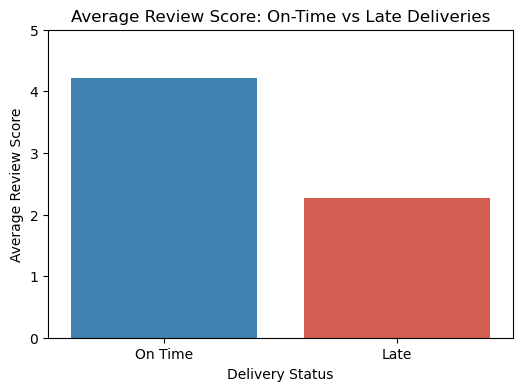

In [ ]:
avg_scores = orders_reviews.groupby('is_late')['review_score'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=avg_scores.index, y=avg_scores.values, palette=['#2E86C1', '#E74C3C'])
plt.xticks([0,1], ['On Time', 'Late'])
plt.ylabel('Average Review Score')
plt.title('Average Review Score: On-Time vs Late Deliveries')
plt.ylim(0,5)
plt.xlabel('Delivery Status')
plt.show()

### Sales Revenue & Sales Analysis
-Building a merged dataframe combining order items, products, 
 categories, and order dates for revenue analysis.

In [ ]:
# Merge order_items with orders (to get purchase date and status)
sales = order_items.merge(orders[['order_id', 'order_purchase_timestamp', 'order_status']], on='order_id', how='left')

# Merge with products to get category
sales = sales.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

# Translate category to English
sales = sales.merge(category_translation, on='product_category_name', how='left')

# Create revenue column
sales['revenue'] = sales['price'] + sales['freight_value']

# Extract month and year
sales['order_month'] = sales['order_purchase_timestamp'].dt.to_period('M')
sales['order_year'] = sales['order_purchase_timestamp'].dt.year

sales[['order_id', 'product_category_name_english', 'price', 'freight_value', 'revenue', 'order_month']].head()

,order_id,product_category_name_english,price,freight_value,revenue,order_month
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,58.90,13.29,72.19,2017-09
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,239.90,19.93,259.83,2017-04
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,199.00,17.87,216.87,2018-01
3,00024acbcdf0a6daa1e931b038114c75,perfumery,12.99,12.79,25.78,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,199.90,18.14,218.04,2017-02


### Monthly Revenue Trend

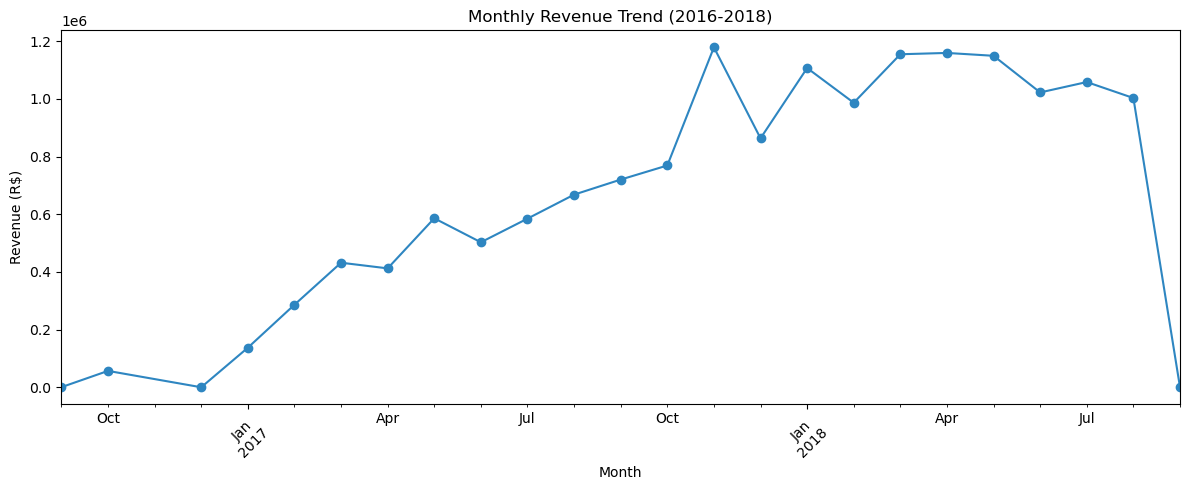

In [ ]:
monthly_revenue = sales.groupby('order_month')['revenue'].sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot(kind='line', marker='o', color='#2E86C1')
plt.title('Monthly Revenue Trend (2016-2018)')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Findings:
- Strong consistent growth from late 2016 through 2018
- Clear spike in Nov 2017 (Black Friday)
- Sharp drop in Sep 2018 — confirmed as incomplete data at dataset cutoff, not actual decline

### Top product categories by revenue

C:\Users\DELL\AppData\Local\Temp\ipykernel_12492\2986728131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='Blues_r')


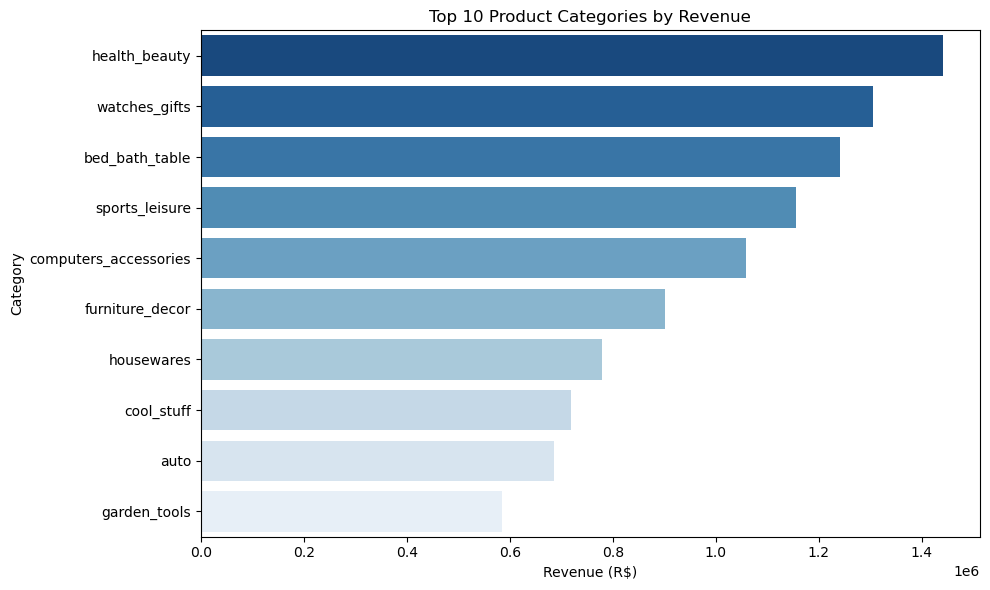

In [ ]:
top_categories = sales.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='Blues_r')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue (R$)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### Findings:
- Health & Beauty leads at ~R$1.44M, followed by Watches & Gifts and 
 Bed/Bath/Table — consistent with Excel pivot table results

### Merge sales with customer state

In [ ]:
sales_full = sales.merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
sales_full = sales_full.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

state_revenue = sales_full.groupby('customer_state')['revenue'].sum().sort_values(ascending=False)
state_pct = (state_revenue / state_revenue.sum() * 100).round(2)

pd.DataFrame({'revenue': state_revenue, 'pct_of_total': state_pct}).head(10)

,revenue,pct_of_total
customer_state,,
SP,5921678.12,37.38
RJ,2129681.98,13.44
MG,1856161.49,11.72
RS,885826.76,5.59
PR,800935.44,5.06
BA,611506.67,3.86
SC,610213.60,3.85
DF,353229.44,2.23
GO,347706.93,2.19


### Findings:
- São Paulo alone accounts for 37.4% of total revenue
- Top 3 states (São Paulo, Rio de Janeiro, Minas Gerais) = 62.5% of revenue combined
- Revenue is heavily concentrated in Brazil's southeast region

### Top categories by Average Order Value

C:\Users\DELL\AppData\Local\Temp\ipykernel_12492\1547116708.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aov_category.values, y=aov_category.index, palette='Greens_r')


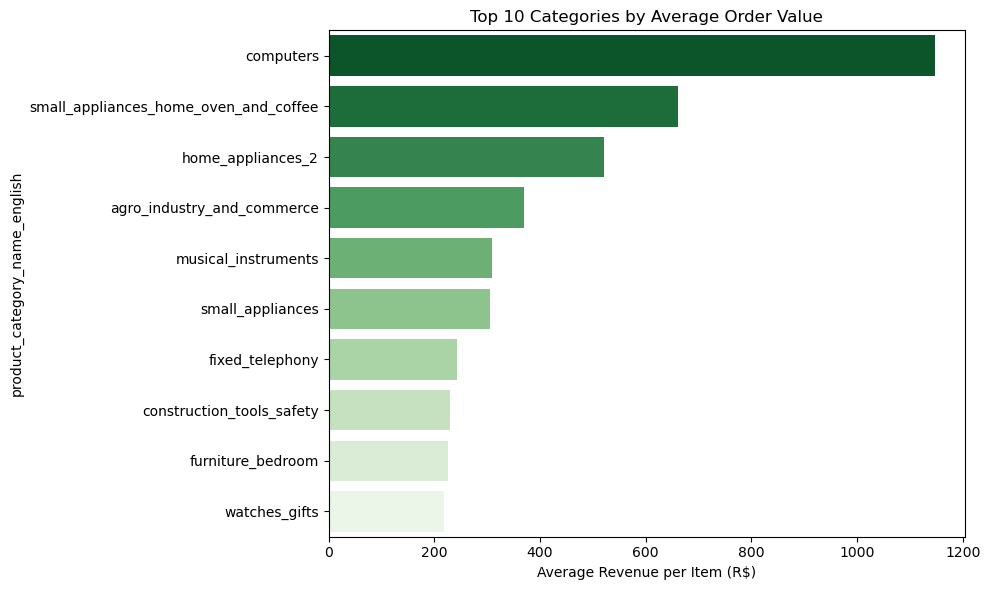

In [ ]:
aov_category = sales.groupby('product_category_name_english')['revenue'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=aov_category.values, y=aov_category.index, palette='Greens_r')
plt.title('Top 10 Categories by Average Order Value')
plt.xlabel('Average Revenue per Item (R$)')
plt.tight_layout()
plt.show()

### Findings:
- "computers" has the highest average order value (~R$1,150) but didn't 
 appear in the top 10 by total revenue — likely low order volume but high price per item
- This is a "low volume, high value" category — potential for premium marketing/upselling strategies
- Contrasts with categories like Health & Beauty, which drive volume but have lower individual order values

### Note on Customer Segmentation
Checked feasibility of RFM (Recency/Frequency/Monetary) segmentation. 
Found that ~96.7% of customers (96,096 of 99,441 unique customer_unique_id) 
made only a single purchase — repeat purchase behavior is rare in this 
dataset. RFM segmentation was not pursued as it would not yield 
meaningful segments given this one-time-buyer-dominant pattern. 
This itself is a notable finding: customer retention may be an area 
worth strategic investment.

## Summary of Key Insights & Recommendations

1. **Revenue**: Strong growth 2016-2018, with seasonal Black Friday spike 
   (Nov 2017). Sept 2018 drop is a data cutoff artifact, not a decline.

2. **Delivery**: Only 6.6% of orders are late, and orders arrive ~12 days 
   earlier than estimated on average — strong logistics performance.

3. **Customer Satisfaction**: Late deliveries nearly halve review scores 
   (4.21 → 2.27). Recommendation: prioritize at-risk shipments.

4. **Categories**: Health & Beauty drives the most total revenue, while 
   "computers" has the highest average order value — different strategies 
   apply (volume vs premium positioning).

5. **Geography**: São Paulo, Rio de Janeiro, and Minas Gerais account for 62.5% of revenue — business 
   is heavily concentrated in southeast Brazil, presenting both 
   opportunity (deepen penetration) and risk (regional dependency).

6. Customer retention is low (96.7% one-time buyers) — a potential growth lever.